In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy import integrate

#### Upside-down Bathtub-shaped Hazard Rate 
Let $Z_1$ and $Z_2$ be independent exponential random variables with different parameters $\beta_1>0$ and $\beta_2>0$, respectively. That is,
$$
\mathbb{P}(Z_i>t) = e^{-\beta_1 t }, \quad t\geq 0, \quad i=1,2.  
$$


Define $X_1 = Z_1 \vee Z_2$. Then its survival function, mean residual life function and expectation are
$$
\overline{F}(t) = e^{-\beta_1 t }+ e^{-\beta_2 t } - e^{-(\beta_1 + \beta_2)t}, \quad m(t) =  \frac{I(t)}{\overline{F}(t)}, \quad t\geq 0 \qquad \text{ and } \qquad a= \frac{1}{\beta_1} + \frac{1}{\beta_2}  - \frac{1}{\beta_1+\beta_2},
$$
where $I(t)=\frac{e^{-\beta_1 t } }{\beta_1} - \frac{e^{-\beta_2 t } }{\beta_2} + \frac{ e^{-(\beta_1 + \beta_2)t } }{\beta_1+\beta_2}$.

The hazard rate of $X_1$ is given by
$$
r(t) = \frac{ \beta_1\, e^{\beta_2 t} + \beta_2\, e^{\beta_1 t} - \beta_1-\beta_2}{ e^{\beta_1 t} + e^{\beta_2 t} - 1 }, \qquad t\geq0, 
$$
and it is well known that $r(t)$ is upside-down bathtub-shaped, as illustrated below. 

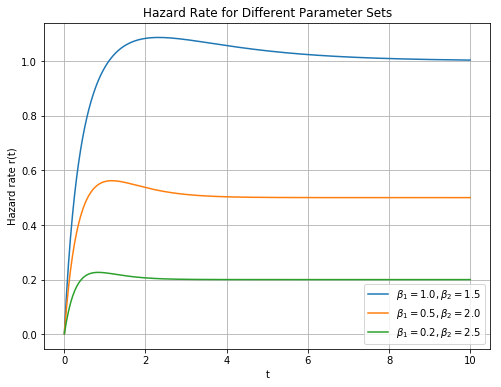

In [2]:
# Hazard function
def hazard_ubfr(t, beta1, beta2):
    num = beta1 * np.exp(beta2*t) + beta2 * np.exp(beta1*t) - beta1 - beta2
    den = np.exp(beta1*t) + np.exp(beta2*t) - 1
    return num/den

# Time grid 
t = np.linspace(0.001, 10, 200)

# Parameter sets (k1, beta1, k2, beta2)
param_sets = [ 
    (1.0, 1.5),
    (0.5, 2.0),
    (0.2, 2.5), 
]

# Create figure
plt.figure(figsize=(8, 6))

for beta1, beta2 in param_sets:
    r = hazard_ubfr(t, beta1, beta2)
    plt.plot(t, r, label = f"$\\beta_1={beta1}, \\beta_2={beta2}$"

)

plt.xlabel("t")
plt.ylabel("Hazard rate r(t)")
plt.title("Hazard Rate for Different Parameter Sets")
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("hazard_ubfr_plot.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

Setting $\gamma_1 = 0.01$, $\gamma_2 = 6$, and $\lambda =0.1$, we verify graphically that the condition 
$$
m(c) < \frac{a(\gamma_2 - \gamma_1)}{\lambda+\gamma_2}
$$ 
holds, where $c = \arg\min m$. This condition ensures the existence of both $\mathrm{T}_0$ and $\mathrm{T}^*$.

For 1.0 and 1.5 , min m should be below 1.2438251366120219
For 0.5 and 2.0 , min m should be below 2.062131147540984
For 0.2 and 2.5 , min m should be below 4.9389313904068


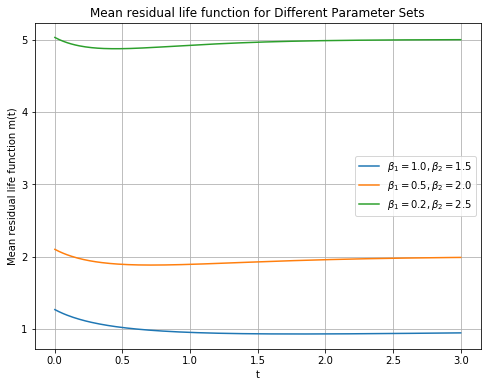

In [4]:
# MRL function
def mrl_ubfr(t, beta1, beta2):
    num = np.exp(beta2*t)/beta1 + np.exp(beta1*t)/beta2 - 1/(beta1 + beta2)
    den = np.exp(beta1*t) + np.exp(beta2*t) - 1
    return num/den

# Time grid 
t = np.linspace(0.001,3, 200)

# Parameter sets (k1, beta1, k2, beta2)
param_sets = [ 
    (1.0, 1.5),
    (0.5, 2.0),
    (0.2, 2.5), 
]
gamma1 = 0.01
gamma2 = 6
lam = .1

# Create figure
plt.figure(figsize=(8, 6))

for beta1, beta2 in param_sets:
    m = mrl_ubfr(t, beta1, beta2)
    plt.plot(t, m, label = f"$\\beta_1={beta1}, \\beta_2={beta2}$")
    
    K = (1/beta1 + 1/beta2 - 1/(beta1 + beta2)) * (1-(lam + gamma1)/(lam+gamma2) )
    print('For', beta1, 'and', beta2 ,', min m should be below', K)

plt.xlabel("t")
plt.ylabel("Mean residual life function m(t)")
plt.title("Mean residual life function for Different Parameter Sets")
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("mrl_ubfr_plot.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

We already know that the mean time to system failure is
$$
\mathcal{M}(\mathrm{T}) = \frac{1}{\lambda} \left(1 + \frac{\displaystyle (\lambda + \gamma_1) (\lambda + \gamma_2) \left( a - I(\mathrm{T}) \right)}{ \lambda + \gamma_2 - \left( \gamma_2 - \gamma_1 \right) \overline{F}(\mathrm{T}) }\right).
$$
When no PM is performed, the mean time to failure is then
$$
\mathcal{M}(\infty) = \frac{1}{\lambda}\left(1+(\lambda + \gamma_1 ) \left( \frac{1}{\beta_1} + \frac{1}{\beta_2}  - \frac{1}{\beta_1+\beta_2} \right) \right).
$$

Since $m(c) < \frac{a(\gamma_2 - \gamma_1)}{\lambda+\gamma_2}$, the threshold time $\mathrm{T}_0$ and the optimal maintenance time $\mathrm{T}^*$ exist. Moreover, $\mathrm{T}_0$ is computed numerically as the unique solution to
$$
m(t) =  \frac{(\gamma_2 - \gamma_1)}{\lambda+\gamma_2} \left( \frac{1}{\beta_1} + \frac{1}{\beta_2} - \frac{1}{\beta_1 + \beta_2} \right),
$$
and $\mathrm{T}^*$ is the unique solution to
$$
r(t) \left( \frac{1}{\beta_1} + \frac{1}{\beta_2} - \frac{1}{\beta_1+\beta_2} - I(t) \right) + \overline{F}(t) = \frac{\lambda+\gamma_2}{(\gamma_2 - \gamma_1)}.
$$

We plot the difference $\mathcal{M}(\mathrm{T}) - \mathcal{M}(\infty)$.

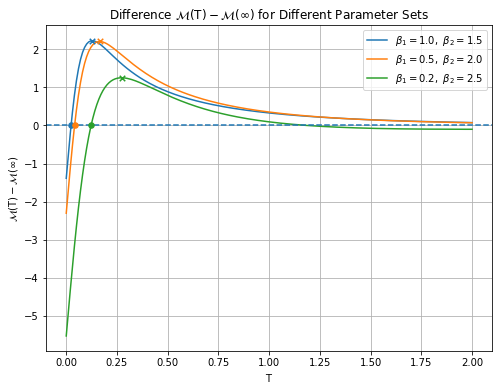

In [5]:
# Parameter sets
param_sets = [
    (1.0, 1.5, 0.01, 6, 0.1),
    (0.5, 2.0, 0.01, 6, 0.1),
    (0.2, 2.5, 0.01, 6, 0.1),
]

T_vals = np.linspace(.0001, 2, 200)

plt.figure(figsize=(8,6))

for i, (beta1, beta2, gamma1, gamma2, lam) in enumerate(param_sets):

    # M(T)
    def M_T(T):
        num = (1-np.exp(-T*beta1))/beta1 + (1-np.exp(-T*beta2))/beta2 - (1-np.exp(-T*(beta1+beta2)))/(beta1+beta2)
        denom = 1/(lam + gamma1) - ( 1/(lam+gamma1) - 1/(lam+gamma2) ) * ( np.exp(-T*beta1)+np.exp(-T*beta2) - np.exp(-T*(beta1+beta2)) )
        return (1/lam) * (1 + num / denom)

    # M(infty)
    M_inf = (1/lam) * (1 + (lam + gamma1)*(1/beta1 + 1/beta2 - 1/(beta1+beta2) ) )

    # Difference
    diff = lambda T: M_T(T) - M_inf
    diff_vals = np.array([diff(T) for T in T_vals])

    # K = a (gamma2 - gamma1) / (lambda + gamma2)
    K = (1/beta1 + 1/beta2 - 1/(beta1 + beta2)) * (1-(lam + gamma1)/(lam+gamma2) )
    
    # Function m(t)
    def mrl_ubfr(t, beta1, beta2):
        num = np.exp(beta2*t)/beta1 + np.exp(beta1*t)/beta2 - 1/(beta1 + beta2)
        den = np.exp(beta1*t) + np.exp(beta2*t) - 1
        return num/den
    
    # Solve m(t) = K
    def solve_t(K, beta1, beta2, t_min=0.001, t_max=0.5):
        f = lambda t: mrl_ubfr(t, beta1, beta2) - K
        return brentq(f, t_min, t_max)
    T0 = solve_t(K, beta1, beta2)
    H0 = M_T(T0) - M_inf
    
    # T*
    def varphi(t, beta1, beta2):
        def hazard_ubfr(t, beta1, beta2):
            num = beta1 * np.exp(beta2*t) + beta2 * np.exp(beta1*t) - beta1 - beta2
            den = np.exp(beta1*t) + np.exp(beta2*t) - 1
            return num/den
        def integ(t):
            return (1 - np.exp(-t*beta1))/beta1 + (1 - np.exp(-t*beta2))/beta2 - (1 - np.exp(-t*(beta1+beta2)))/(beta1+beta2)         
        return hazard_ubfr(t, beta1, beta2) * integ(t) + np.exp(-t*beta1)+np.exp(-t*beta2) - np.exp(-t*(beta1+beta2))
    
    # Solve varphi(t) = (lambda + gamma2) / (gamma2 - gamma1)
    mu1_Delta = 1/(1 - (lam + gamma1)/(lam + gamma2) ) 
    
    def solve_opt(mu1_Delta, beta1, beta2, t_min=0.001, t_max=0.5):
        f = lambda t: varphi(t, beta1, beta2) - mu1_Delta
        return brentq(f, t_min, t_max)
    T_opt = solve_opt(mu1_Delta, beta1, beta2)
    H_opt = M_T(T_opt) - M_inf
     
    # Plot
    line, = plt.plot(T_vals, diff_vals, label=f"$\\beta_1={beta1},\\ \\beta_2={beta2}$")
    color = line.get_color()

    plt.scatter(T0, H0, s=30, marker='o', zorder=5, color=color)
    plt.scatter(T_opt, H_opt, s=30, marker='x', zorder=5, color=color)

plt.axhline(0, linestyle="--")
plt.xlabel(r"$\mathrm{T}$")
plt.ylabel(r"$\mathcal{M}(\mathrm{T})-\mathcal{M}(\infty)$")
plt.title(r"Difference $\mathcal{M}(\mathrm{T})-\mathcal{M}(\infty)$ for Different Parameter Sets")
plt.legend()
plt.grid(True)

plt.savefig("M_diff_ubfr_three_sets.png", dpi=300, bbox_inches="tight")
plt.show()

#### Remarks
Numerical values of $\mathrm{T}_0$ and $\mathrm{T}^*$ for different parameter sets are shown in the figure above. In particular, for the green curve, preventive maintenance is beneficial only over a finite time interval. This behavior is consistent with the fact that 
$$
\displaystyle \lim_{t\to\infty} r(t) = \min\{\beta_1, \beta_2\}<\frac{(\gamma_2 - \gamma_1)}{\lambda+\gamma_2} \left( \frac{1}{\beta_1} + \frac{1}{\beta_2} - \frac{1}{\beta_1 + \beta_2} \right).
$$